# Analisis Market Gap Layanan Fiverr

## Judul Proyek

Analisis Market Gap dan Prediksi Potensi Permintaan Layanan Data dan AI
di Fiverr Menggunakan Natural Language Processing dan Machine Learning.

## Tujuan Notebook

Notebook ini digunakan untuk:

1. Memahami struktur dataset mentah.
2. Menganalisis kualitas data.
3. Membersihkan rating, jumlah review, harga, dan seller level.
4. Melakukan exploratory data analysis.
5. Menyiapkan dataset untuk modeling.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RAW_PATH = ROOT / "data" / "raw" / "fiverr-data-gigs.csv"
PROCESSED_PATH = ROOT / "data" / "processed" / "fiverr_gigs_cleaned.csv"
FIGURES_PATH = ROOT / "reports" / "figures"

FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print("Folder proyek :", ROOT)
print("Dataset mentah:", RAW_PATH)
print("Dataset ada   :", RAW_PATH.exists())

Folder proyek : c:\Users\USER\Downloads\fiverr-market-gap
Dataset mentah: c:\Users\USER\Downloads\fiverr-market-gap\data\raw\fiverr-data-gigs.csv
Dataset ada   : True


In [2]:
df_raw = pd.read_csv(RAW_PATH)

print("Jumlah baris :", df_raw.shape[0])
print("Jumlah kolom :", df_raw.shape[1])

display(df_raw.head())

Jumlah baris : 1259
Jumlah kolom : 5


,Title,Title_URL,gigrating,_5fo9i5,Price
0,"I will do excel formulas, vba macros, charts, forms, addins",https://www.fiverr.com/maltehar/do-excel-formulas-vba-macros-charts-forms-addins?context_referrer=subcategory_listin...,5.0(56),Level 2 Seller,"PKR 8,701"
1,"I will do data mining, web scraping, data extraction,excel CSV job",https://www.fiverr.com/hotopilams/do-data-mining-data-extraction-or-web-scraping?context_referrer=subcategory_listin...,5.0(1k+),Top Rated Seller,"PKR 3,263"
2,"I will do web scraping , data scraping, scraping emails, website scraping",https://www.fiverr.com/kodweb/do-web-scraping-data-mining-web-crawler-and-bots?context_referrer=subcategory_listing&...,5.0(63),Level 2 Seller,"PKR 2,176"
3,"I will do python web scraping , data entry , and data extraction",https://www.fiverr.com/asad__haadi/do-web-scraping-virtual-assistant-for-data-entry-and-web-search-excel-sheets?cont...,5.0(266),Level 2 Seller,"PKR 1,088"
4,I will data scraping web site scraping and data collection,https://www.fiverr.com/yourbuddy/web-scraping-and-data-mining-for-any-website?context_referrer=subcategory_listing&s...,4.9(275),Level 2 Seller,"PKR 4,351"


In [3]:
df_raw.info()
display(
    df_raw.dtypes.to_frame("tipe_data")
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Title      1259 non-null   object
 1   Title_URL  1259 non-null   object
 2   gigrating  629 non-null    object
 3   _5fo9i5    432 non-null    object
 4   Price      1259 non-null   object
dtypes: object(5)
memory usage: 49.3+ KB


,tipe_data
Title,object
Title_URL,object
gigrating,object
_5fo9i5,object
Price,object


Seluruh kolom pada dataset mentah masih bertipe object atau teks.
Kolom rating dan jumlah review masih tergabung dalam `gigrating`,
sedangkan harga masih mengandung simbol mata uang PKR dan tanda koma.
Oleh karena itu, beberapa kolom harus diurai dan dikonversi menjadi
tipe numerik sebelum digunakan dalam analisis dan modeling.

,jumlah_missing,persentase_missing
Title,0,0.00
Title_URL,0,0.00
gigrating,630,50.04
_5fo9i5,827,65.69
Price,0,0.00


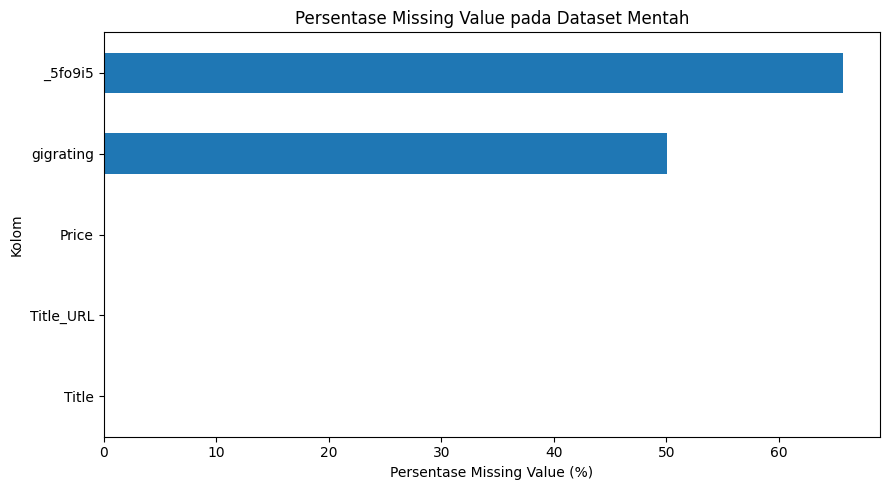

In [4]:
missing_raw = pd.DataFrame(
    {
        "jumlah_missing": df_raw.isna().sum(),
        "persentase_missing": (
            df_raw.isna().mean() * 100
        ).round(2),
    }
)

display(missing_raw)

plt.figure(figsize=(9, 5))

missing_raw["persentase_missing"].sort_values().plot(
    kind="barh"
)

plt.title("Persentase Missing Value pada Dataset Mentah")
plt.xlabel("Persentase Missing Value (%)")
plt.ylabel("Kolom")
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "01_missing_values.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [5]:
print(
    "Duplikat seluruh baris:",
    df_raw.duplicated().sum(),
)

print(
    "Duplikat judul:",
    df_raw.duplicated(subset=["Title"]).sum(),
)

print(
    "Duplikat URL:",
    df_raw.duplicated(subset=["Title_URL"]).sum(),
)

Duplikat seluruh baris: 0
Duplikat judul: 76
Duplikat URL: 0


In [6]:
SRC_PATH = ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from clean_data import clean_data

df = clean_data(df_raw)

print("Ukuran data mentah :", df_raw.shape)
print("Ukuran data bersih :", df.shape)

display(df.head())

Ukuran data mentah : (1259, 5)
Ukuran data bersih : (1259, 15)


,gig_title,gig_url,rating_raw,seller_level_raw,price_raw,rating,review_count,price_pkr,seller_level,title_clean,title_word_count,seller_username,listing_position,log_price_pkr,log_review_count
0,"I will do excel formulas, vba macros, charts, forms, addins",https://www.fiverr.com/maltehar/do-excel-formulas-vba-macros-charts-forms-addins?context_referrer=subcategory_listin...,5.0(56),Level 2 Seller,"PKR 8,701",5.0,56,8701,Level 2 Seller,i will do excel formulas vba macros charts forms addins,10,maltehar,1,9.071308,4.043051
1,"I will do data mining, web scraping, data extraction,excel CSV job",https://www.fiverr.com/hotopilams/do-data-mining-data-extraction-or-web-scraping?context_referrer=subcategory_listin...,5.0(1k+),Top Rated Seller,"PKR 3,263",5.0,1000,3263,Top Rated Seller,i will do data mining web scraping data extraction excel csv job,12,hotopilams,2,8.090709,6.908755
2,"I will do web scraping , data scraping, scraping emails, website scraping",https://www.fiverr.com/kodweb/do-web-scraping-data-mining-web-crawler-and-bots?context_referrer=subcategory_listing&...,5.0(63),Level 2 Seller,"PKR 2,176",5.0,63,2176,Level 2 Seller,i will do web scraping data scraping scraping emails website scraping,11,kodweb,3,7.685703,4.158883
3,"I will do python web scraping , data entry , and data extraction",https://www.fiverr.com/asad__haadi/do-web-scraping-virtual-assistant-for-data-entry-and-web-search-excel-sheets?cont...,5.0(266),Level 2 Seller,"PKR 1,088",5.0,266,1088,Level 2 Seller,i will do python web scraping data entry and data extraction,11,asad__haadi,4,6.993015,5.587249
4,I will data scraping web site scraping and data collection,https://www.fiverr.com/yourbuddy/web-scraping-and-data-mining-for-any-website?context_referrer=subcategory_listing&s...,4.9(275),Level 2 Seller,"PKR 4,351",4.9,275,4351,Level 2 Seller,i will data scraping web site scraping and data collection,10,yourbuddy,5,8.378391,5.620401


In [7]:
print(df.columns.tolist())

display(
    df[
        [
            "rating_raw",
            "rating",
            "review_count",
            "price_raw",
            "price_pkr",
            "seller_level",
        ]
    ].head(15)
)

['gig_title', 'gig_url', 'rating_raw', 'seller_level_raw', 'price_raw', 'rating', 'review_count', 'price_pkr', 'seller_level', 'title_clean', 'title_word_count', 'seller_username', 'listing_position', 'log_price_pkr', 'log_review_count']


,rating_raw,rating,review_count,price_raw,price_pkr,seller_level
0,5.0(56),5.0,56,"PKR 8,701",8701,Level 2 Seller
1,5.0(1k+),5.0,1000,"PKR 3,263",3263,Top Rated Seller
2,5.0(63),5.0,63,"PKR 2,176",2176,Level 2 Seller
3,5.0(266),5.0,266,"PKR 1,088",1088,Level 2 Seller
4,4.9(275),4.9,275,"PKR 4,351",4351,Level 2 Seller
5,5.0(181),5.0,181,"PKR 2,176",2176,Level 2 Seller
6,5.0(211),5.0,211,"PKR 10,876",10876,Top Rated Seller
7,5.0(398),5.0,398,"PKR 17,401",17401,Top Rated Seller
8,5.0(61),5.0,61,"PKR 4,351",4351,Level 2 Seller
9,5.0(16),5.0,16,"PKR 21,752",21752,Unknown


In [8]:
assert df["rating"].dropna().between(0, 5).all()
assert (df["price_pkr"].dropna() > 0).all()
assert (df["review_count"].dropna() >= 0).all()

print("Validasi nilai berhasil.")

Validasi nilai berhasil.


In [9]:
numeric_columns = [
    "rating",
    "review_count",
    "price_pkr",
    "title_word_count",
]

display(
    df[numeric_columns]
    .describe()
    .T
)

summary_statistics = pd.DataFrame(
    {
        "mean": df[numeric_columns].mean(),
        "median": df[numeric_columns].median(),
        "minimum": df[numeric_columns].min(),
        "maximum": df[numeric_columns].max(),
        "missing": df[numeric_columns].isna().sum(),
    }
)

display(summary_statistics)

,count,mean,std,min,25%,50%,75%,max
rating,629.0,4.955167,0.186638,1.0,5.0,5.0,5.0,5.0
review_count,629.0,77.802862,179.537993,1.0,4.0,16.0,55.0,1000.0
price_pkr,1259.0,14993.085782,70785.249092,1088.0,2176.0,4351.0,10876.0,2175105.0
title_word_count,1259.0,10.093725,2.199317,6.0,8.0,10.0,12.0,17.0


,mean,median,minimum,maximum,missing
rating,4.955167,5.0,1.0,5.0,630
review_count,77.802862,16.0,1.0,1000.0,630
price_pkr,14993.085782,4351.0,1088.0,2175105.0,0
title_word_count,10.093725,10.0,6.0,17.0,0


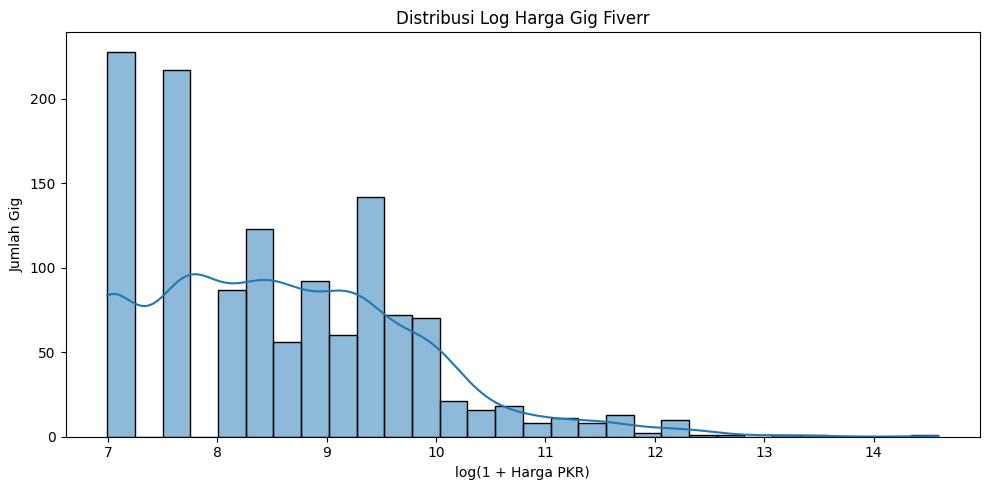

In [10]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="log_price_pkr",
    bins=30,
    kde=True,
)

plt.title("Distribusi Log Harga Gig Fiverr")
plt.xlabel("log(1 + Harga PKR)")
plt.ylabel("Jumlah Gig")
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "02_distribusi_harga.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

,seller_level,jumlah_gig
0,Unknown,834
1,Level 2 Seller,212
2,Level 1 Seller,183
3,Top Rated Seller,30


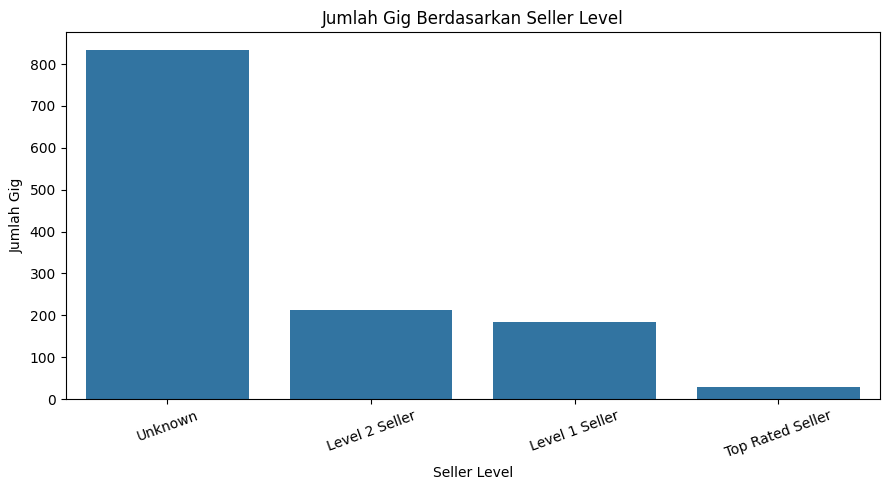

In [11]:
seller_counts = (
    df["seller_level"]
    .value_counts()
    .reset_index()
)

seller_counts.columns = [
    "seller_level",
    "jumlah_gig",
]

display(seller_counts)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=seller_counts,
    x="seller_level",
    y="jumlah_gig",
)

plt.title("Jumlah Gig Berdasarkan Seller Level")
plt.xlabel("Seller Level")
plt.ylabel("Jumlah Gig")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "03_seller_level.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

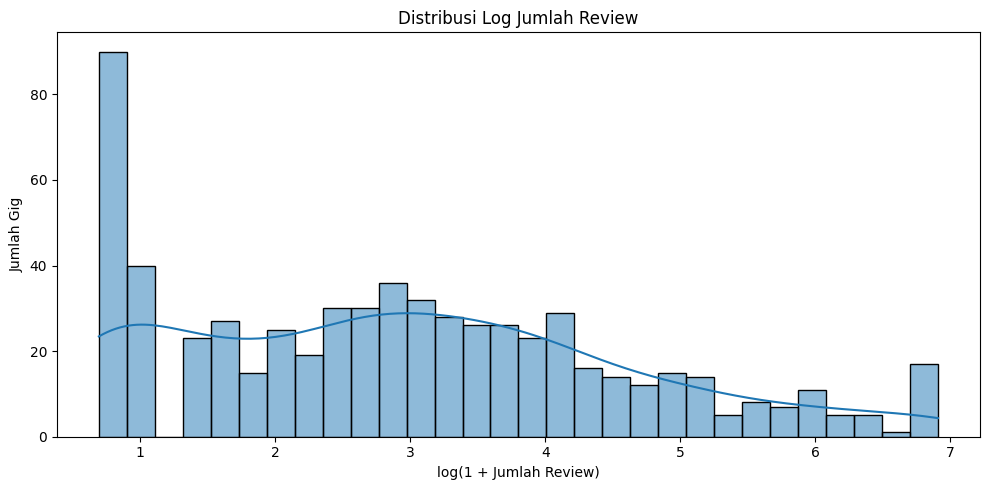

In [12]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="log_review_count",
    bins=30,
    kde=True,
)

plt.title("Distribusi Log Jumlah Review")
plt.xlabel("log(1 + Jumlah Review)")
plt.ylabel("Jumlah Gig")
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "04_distribusi_review.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

,seller_level,price_pkr
0,Top Rated Seller,15770.0
1,Level 1 Seller,5438.0
2,Level 2 Seller,4351.0
3,Unknown,4351.0


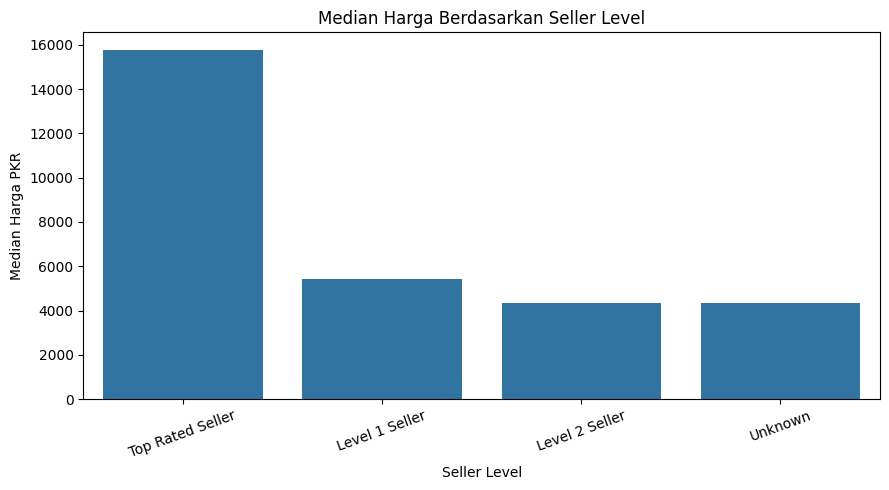

In [14]:
median_price_level = (
    df.groupby("seller_level")["price_pkr"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

display(median_price_level)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=median_price_level,
    x="seller_level",
    y="price_pkr",
)

plt.title("Median Harga Berdasarkan Seller Level")
plt.xlabel("Seller Level")
plt.ylabel("Median Harga PKR")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "05_harga_seller_level.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [16]:
scatter_data = df.dropna(
    subset=[
        "log_price_pkr",
        "log_review_count",
    ]
)

fig = px.scatter(
    scatter_data,
    x="log_price_pkr",
    y="log_review_count",
    color="seller_level",
    hover_data=["gig_title"],
    title="Hubungan Harga dan Jumlah Review",
    labels={
        "log_price_pkr": "Log Harga",
        "log_review_count": "Log Jumlah Review",
    },
)

fig.show()

,term,frequency
2,data,761
19,python,303
14,learning,207
15,machine,159
25,using,156
16,machine learning,149
11,excel,144
28,web,142
21,scraping,125
10,etl,116


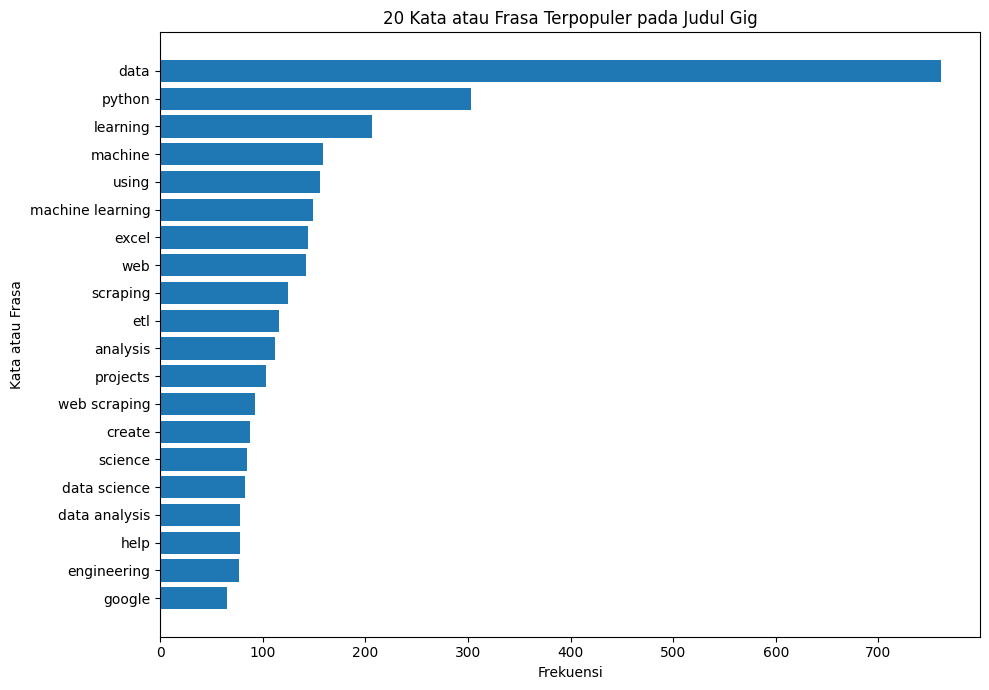

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_features=30,
)

word_matrix = count_vectorizer.fit_transform(
    df["title_clean"]
)

word_frequency = np.asarray(
    word_matrix.sum(axis=0)
).ravel()

top_words = pd.DataFrame(
    {
        "term": count_vectorizer.get_feature_names_out(),
        "frequency": word_frequency,
    }
).sort_values(
    "frequency",
    ascending=False,
)

display(top_words.head(20))

top_20_words = top_words.head(20).sort_values(
    "frequency"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_20_words["term"],
    top_20_words["frequency"],
)

plt.title("20 Kata atau Frasa Terpopuler pada Judul Gig")
plt.xlabel("Frekuensi")
plt.ylabel("Kata atau Frasa")
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "06_top_keywords.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [18]:
PROCESSED_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

df.to_csv(
    PROCESSED_PATH,
    index=False,
)

print("Dataset disimpan:", PROCESSED_PATH)

df_check = pd.read_csv(PROCESSED_PATH)

print(df_check.shape)
display(df_check.head())

Dataset disimpan: c:\Users\USER\Downloads\fiverr-market-gap\data\processed\fiverr_gigs_cleaned.csv
(1259, 15)


,gig_title,gig_url,rating_raw,seller_level_raw,price_raw,rating,review_count,price_pkr,seller_level,title_clean,title_word_count,seller_username,listing_position,log_price_pkr,log_review_count
0,"I will do excel formulas, vba macros, charts, forms, addins",https://www.fiverr.com/maltehar/do-excel-formulas-vba-macros-charts-forms-addins?context_referrer=subcategory_listin...,5.0(56),Level 2 Seller,"PKR 8,701",5.0,56.0,8701,Level 2 Seller,i will do excel formulas vba macros charts forms addins,10,maltehar,1,9.071308,4.043051
1,"I will do data mining, web scraping, data extraction,excel CSV job",https://www.fiverr.com/hotopilams/do-data-mining-data-extraction-or-web-scraping?context_referrer=subcategory_listin...,5.0(1k+),Top Rated Seller,"PKR 3,263",5.0,1000.0,3263,Top Rated Seller,i will do data mining web scraping data extraction excel csv job,12,hotopilams,2,8.090709,6.908755
2,"I will do web scraping , data scraping, scraping emails, website scraping",https://www.fiverr.com/kodweb/do-web-scraping-data-mining-web-crawler-and-bots?context_referrer=subcategory_listing&...,5.0(63),Level 2 Seller,"PKR 2,176",5.0,63.0,2176,Level 2 Seller,i will do web scraping data scraping scraping emails website scraping,11,kodweb,3,7.685703,4.158883
3,"I will do python web scraping , data entry , and data extraction",https://www.fiverr.com/asad__haadi/do-web-scraping-virtual-assistant-for-data-entry-and-web-search-excel-sheets?cont...,5.0(266),Level 2 Seller,"PKR 1,088",5.0,266.0,1088,Level 2 Seller,i will do python web scraping data entry and data extraction,11,asad__haadi,4,6.993015,5.587249
4,I will data scraping web site scraping and data collection,https://www.fiverr.com/yourbuddy/web-scraping-and-data-mining-for-any-website?context_referrer=subcategory_listing&s...,4.9(275),Level 2 Seller,"PKR 4,351",4.9,275.0,4351,Level 2 Seller,i will data scraping web site scraping and data collection,10,yourbuddy,5,8.378391,5.620401


# Lima Insight Utama

1. **Kualitas data**
   Kolom rating dan review mempunyai missing value yang cukup besar,
   sehingga data tanpa target tidak digunakan untuk supervised learning.

2. **Distribusi harga**
   Harga gig mempunyai distribusi right-skewed dan beberapa nilai sangat
   tinggi. Transformasi log digunakan tanpa langsung menghapus outlier.

3. **Seller level**
   Sebagian besar data seller level masuk kategori ... berdasarkan hasil
   distribusi yang diperoleh.

4. **Jumlah review**
   Distribusi review sangat tidak seimbang. Sebagian besar gig memiliki
   review relatif sedikit, sedangkan beberapa gig mempunyai review tinggi.

5. **Topik layanan**
   Kata atau frasa yang sering muncul menunjukkan dominasi layanan seperti
   ... Isi berdasarkan visualisasi keyword yang dihasilkan.